In [1]:
# ── Cell 1: Install / Import ──────────────────────────────────────────────────
import os, zipfile, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
import cv2
from google.colab import files
from IPython.display import display, Image as IPImage

print(f'TF version : {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TF version : 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ── Cell 2: Upload & Load the Saved Model ────────────────────────────────────
print('Upload your  plant_disease_efficientnet_final.keras  (or .h5) file:')
uploaded_model = files.upload()
MODEL_PATH = list(uploaded_model.keys())[0]

print(f'\nLoading model from: {MODEL_PATH} …')
model = tf.keras.models.load_model(MODEL_PATH)
print('Model loaded successfully!')
model.summary()

Upload your  plant_disease_efficientnet_final.keras  (or .h5) file:


In [ ]:
# ── Cell 3: Class Names (38 PlantVillage classes) ────────────────────────────
# These must match the order used during training (alphabetical from flow_from_directory).
CLASS_NAMES = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch',
    'Strawberry___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

IMG_SIZE  = 224
TOP_N     = 5    # how many predictions to show in the bar chart

print(f'{len(CLASS_NAMES)} classes registered.')

✅ 38 classes registered.


In [ ]:
# ── Cell 4: Core Helper Functions ────────────────────────────────────────────

def preprocess_image(img_path: str):
    """Load and normalise an image; return (display_array, input_tensor)."""
    img      = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr  = tf.keras.preprocessing.image.img_to_array(img) / 255.0   # [0,1]
    tensor   = np.expand_dims(img_arr, axis=0)                          # (1,224,224,3)
    return img_arr, tensor


def get_gradcam_heatmap(img_tensor, model, last_conv_layer: str = 'top_conv'):
    """
    Compute Grad-CAM heatmap for the predicted class.
    Works with your Sequential(EfficientNetB0 + head) architecture.
    Returns: smoothed heatmap (224×224), predicted class index, confidence.
    """
    base_model = model.layers[0]   # EfficientNetB0

    grad_model = tf.keras.models.Model(
        inputs  = base_model.inputs,
        outputs = [base_model.get_layer(last_conv_layer).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_output, base_output = grad_model(img_tensor)

        # Pass base output through the classification head
        x = base_output
        for layer in model.layers[1:]:
            x = layer(x)
        preds = x

        pred_idx  = int(tf.argmax(preds[0]))
        class_score = preds[:, pred_idx]

    grads        = tape.gradient(class_score, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.squeeze(last_conv_output[0] @ pooled_grads[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)

    # Upsample + smooth
    heatmap_np = cv2.resize(heatmap.numpy(), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
    heatmap_np = cv2.GaussianBlur(heatmap_np, (11, 11), 0)

    confidence = float(tf.reduce_max(preds))
    return heatmap_np, pred_idx, confidence, preds[0].numpy()


def make_research_plate(img_arr, heatmap, all_preds, pred_idx,
                         true_label: str = None, img_filename: str = '',
                         save_path: str = None, top_n: int = 5):
    """
    Draw a 3-panel research figure:
      Panel 1 – Original image
      Panel 2 – Grad-CAM overlay
      Panel 3 – Top-N confidence bar chart
    """
    top_n_idx    = np.argsort(all_preds)[-top_n:][::-1]
    top_n_labels = [CLASS_NAMES[i].replace('___', '\n').replace('_', ' ') for i in top_n_idx]
    top_n_confs  = [all_preds[i] for i in top_n_idx]

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.patch.set_facecolor('#1a1a2e')

    for ax in axes:
        ax.set_facecolor('#16213e')
        for spine in ax.spines.values():
            spine.set_edgecolor('#0f3460')

    # ── Panel 1: Original ────────────────────────────────────────────────────
    axes[0].imshow(img_arr)
    title1 = f'Original Leaf\n{os.path.basename(img_filename)}'
    if true_label:
        title1 += f'\nTrue: {true_label.replace("___", " – ").replace("_", " ")}'
    axes[0].set_title(title1, fontsize=10, color='white', pad=8)
    axes[0].axis('off')

    # ── Panel 2: Grad-CAM overlay ─────────────────────────────────────────────
    axes[1].imshow(img_arr)
    axes[1].imshow(heatmap, cmap='jet', alpha=0.45)
    pred_name = CLASS_NAMES[pred_idx].replace('___', ' – ').replace('_', ' ')
    axes[1].set_title(f'Grad-CAM Heatmap\nPredicted: {pred_name}', fontsize=10, color='white', pad=8)
    axes[1].axis('off')

    # Add colourbar legend
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[1], fraction=0.035, pad=0.04)
    cbar.set_label('Activation Intensity', color='white', fontsize=8)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=7)

    # ── Panel 3: Confidence bar chart ─────────────────────────────────────────
    bar_colors = []
    for i in top_n_idx:
        if i == pred_idx and (true_label is None or CLASS_NAMES[i] == true_label):
            bar_colors.append('#2ecc71')   # green  – correct top prediction
        elif i == pred_idx:
            bar_colors.append('#e74c3c')   # red    – wrong top prediction
        else:
            bar_colors.append('#3498db')   # blue   – other candidates

    bars = axes[2].barh(range(top_n), top_n_confs, color=bar_colors,
                        edgecolor='white', linewidth=0.6)
    axes[2].set_yticks(range(top_n))
    axes[2].set_yticklabels(top_n_labels, fontsize=8.5, color='white')
    axes[2].invert_yaxis()
    axes[2].set_xlim(0, 1.18)
    axes[2].set_xlabel('Confidence', color='white', fontsize=9)
    axes[2].tick_params(axis='x', colors='white', labelsize=8)
    axes[2].set_title(f'Top-{top_n} Predictions', fontsize=10, color='white', pad=8)

    for j, (bar, conf) in enumerate(zip(bars, top_n_confs)):
        axes[2].text(conf + 0.012, j, f'{conf:.2%}',
                     va='center', fontsize=8.5, fontweight='bold', color='white')

    # Legend
    legend_patches = [
        mpatches.Patch(color='#2ecc71', label='Top prediction (correct)'),
        mpatches.Patch(color='#e74c3c', label='Top prediction (wrong)'),
        mpatches.Patch(color='#3498db', label='Other candidates'),
    ]
    axes[2].legend(handles=legend_patches, loc='lower right',
                   fontsize=7.5, framealpha=0.3,
                   labelcolor='white', facecolor='#0f3460')

    plt.tight_layout(pad=1.5)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.close()
    else:
        plt.show()

print('Helper functions defined.')

✅ Helper functions defined.


📂 Upload one or more leaf images (JPG / PNG):


Saving corn-northanr-leaf-blight3.jpg to corn-northanr-leaf-blight3.jpg

🔍 Processing: corn-northanr-leaf-blight3.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


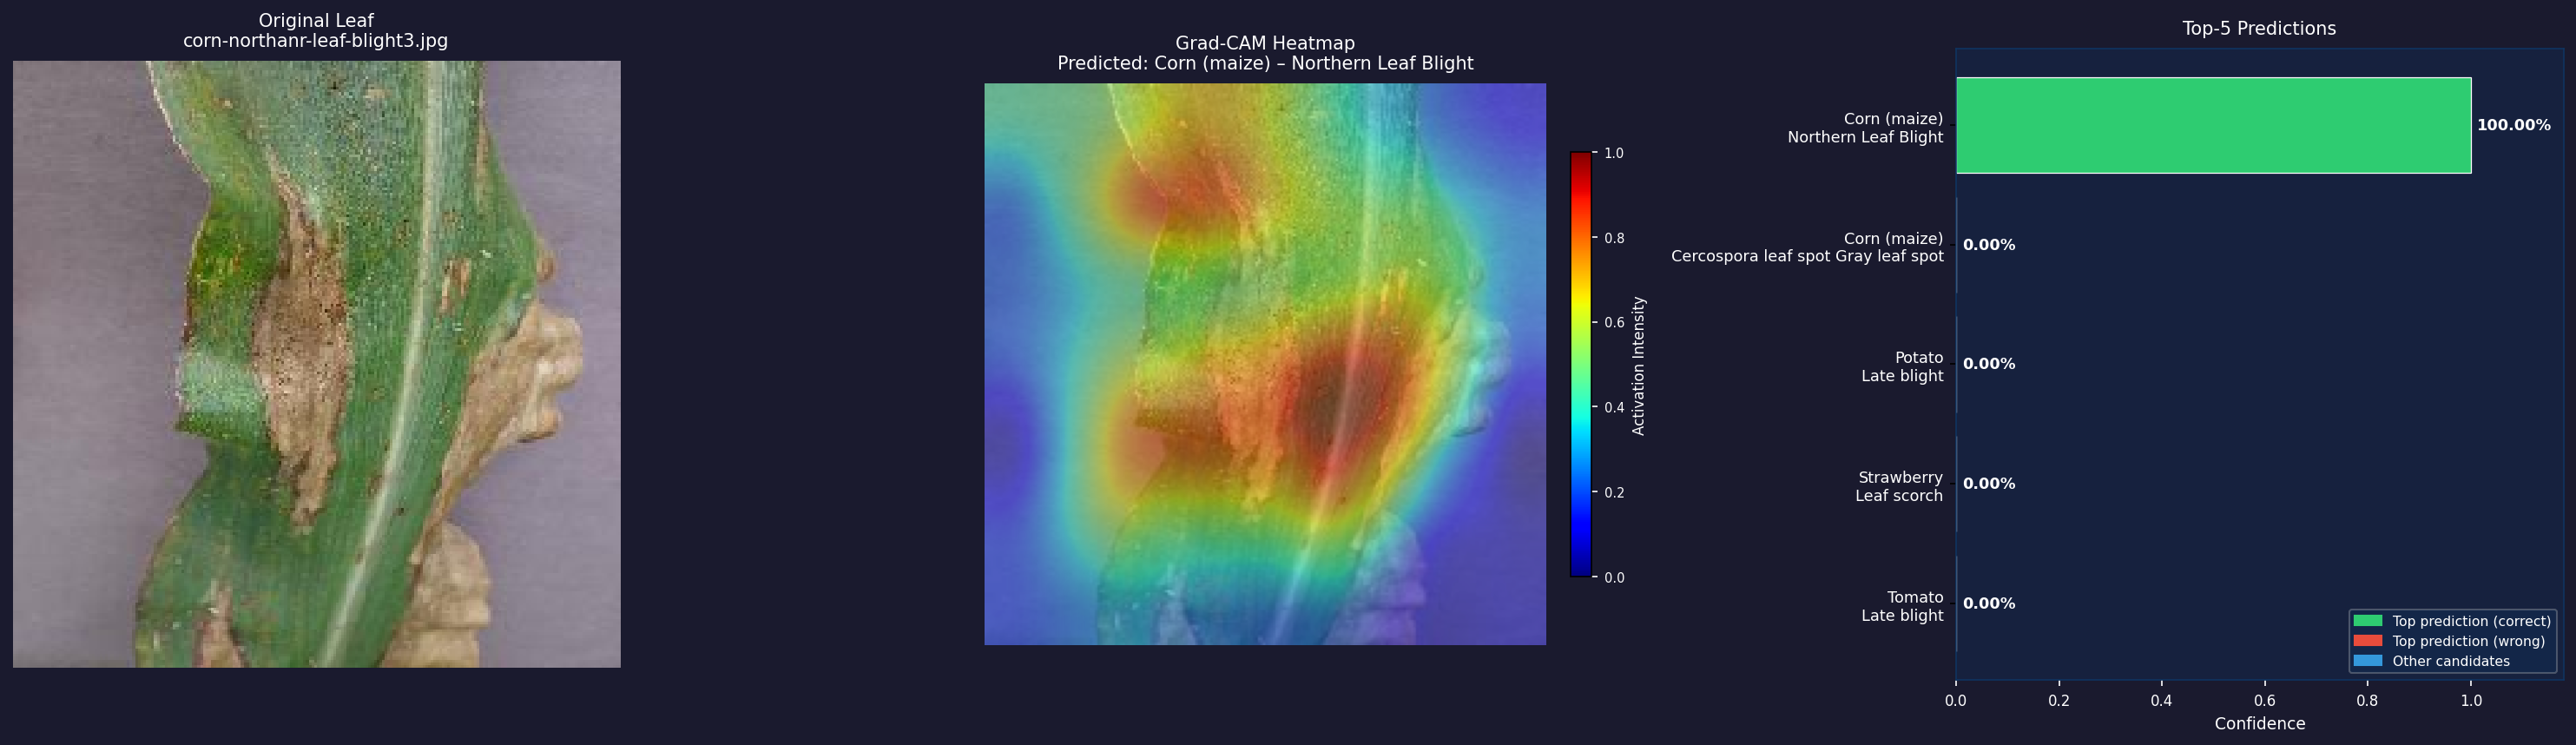

   → Corn_(maize)___Northern_Leaf_Blight  (100.00%)

📊 Summary:


,Image,Prediction,Confidence
0,corn-northanr-leaf-blight3.jpg,Corn_(maize)___Northern_Leaf_Blight,100.00%


In [ ]:
# ── Cell 5: Upload Your Leaf Images & Run Inference ───────────────────────────
#
# You can upload multiple images at once (jpg / jpeg / png).
# Set  TRUE_LABELS  to a dict mapping filename → class name if you want
# the bar chart to colour-code correct vs wrong predictions.
# Leave it as {}  if you only have raw images without ground truth.

TRUE_LABELS = {}   # e.g. {'leaf1.jpg': 'Tomato___Early_blight', ...}

print('Upload one or more leaf images (JPG / PNG):')
uploaded_imgs = files.upload()

OUTPUT_DIR = 'inference_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []

for fname, _ in uploaded_imgs.items():
    print(f'\n Processing: {fname}')

    try:
        img_arr, img_tensor = preprocess_image(fname)
        heatmap, pred_idx, confidence, all_preds = get_gradcam_heatmap(img_tensor, model)
        true_label = TRUE_LABELS.get(fname, None)

        save_path = os.path.join(OUTPUT_DIR, f'result_{os.path.splitext(fname)[0]}.png')

        make_research_plate(
            img_arr      = img_arr,
            heatmap      = heatmap,
            all_preds    = all_preds,
            pred_idx     = pred_idx,
            true_label   = true_label,
            img_filename = fname,
            save_path    = save_path,
            top_n        = TOP_N
        )

        # Show inline
        display(IPImage(save_path))

        pred_name = CLASS_NAMES[pred_idx]
        results.append({'Image': fname, 'Prediction': pred_name, 'Confidence': f'{confidence:.2%}'})
        print(f'   → {pred_name}  ({confidence:.2%})')

    except Exception as e:
        print(f'     Error on {fname}: {e}')

# Summary table
print('\nSummary:')
display(pd.DataFrame(results))

📂 Upload one or more leaf images (JPG / PNG):


Saving potato-late-blight3.jpg to potato-late-blight3.jpg

🔍 Processing: potato-late-blight3.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


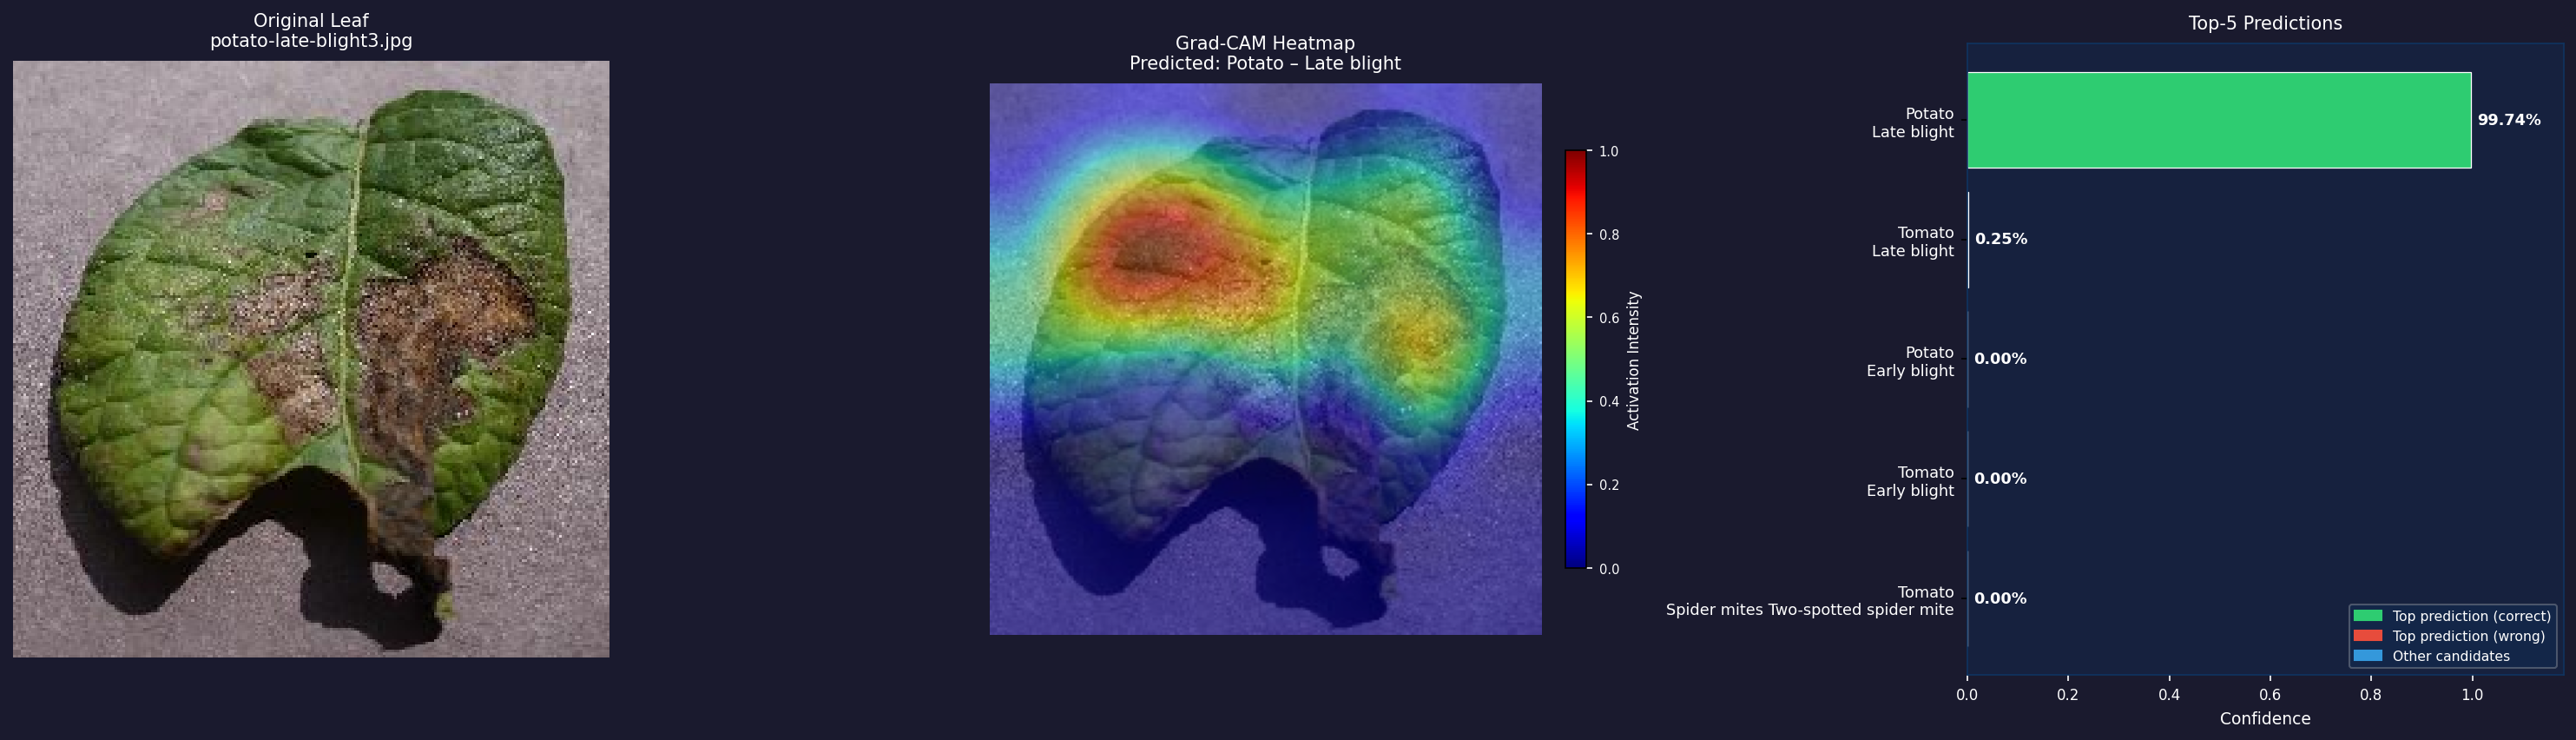

   → Potato___Late_blight  (99.74%)

📊 Summary:


,Image,Prediction,Confidence
0,potato-late-blight3.jpg,Potato___Late_blight,99.74%


In [ ]:
# ── Cell 5: Upload Your Leaf Images & Run Inference ───────────────────────────
#
# You can upload multiple images at once (jpg / jpeg / png).
# Set  TRUE_LABELS  to a dict mapping filename → class name if you want
# the bar chart to colour-code correct vs wrong predictions.
# Leave it as {}  if you only have raw images without ground truth.

TRUE_LABELS = {}   # e.g. {'leaf1.jpg': 'Tomato___Early_blight', ...}

print('Upload one or more leaf images (JPG / PNG):')
uploaded_imgs = files.upload()

OUTPUT_DIR = 'inference_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []

for fname, _ in uploaded_imgs.items():
    print(f'\nProcessing: {fname}')

    try:
        img_arr, img_tensor = preprocess_image(fname)
        heatmap, pred_idx, confidence, all_preds = get_gradcam_heatmap(img_tensor, model)
        true_label = TRUE_LABELS.get(fname, None)

        save_path = os.path.join(OUTPUT_DIR, f'result_{os.path.splitext(fname)[0]}.png')

        make_research_plate(
            img_arr      = img_arr,
            heatmap      = heatmap,
            all_preds    = all_preds,
            pred_idx     = pred_idx,
            true_label   = true_label,
            img_filename = fname,
            save_path    = save_path,
            top_n        = TOP_N
        )

        # Show inline
        display(IPImage(save_path))

        pred_name = CLASS_NAMES[pred_idx]
        results.append({'Image': fname, 'Prediction': pred_name, 'Confidence': f'{confidence:.2%}'})
        print(f'   → {pred_name}  ({confidence:.2%})')

    except Exception as e:
        print(f'   ⚠️  Error on {fname}: {e}')

# Summary table
print('\n📊 Summary:')
display(pd.DataFrame(results))

📂 Upload one or more leaf images (JPG / PNG):


Saving apple-scab2.jpg to apple-scab2.jpg

🔍 Processing: apple-scab2.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


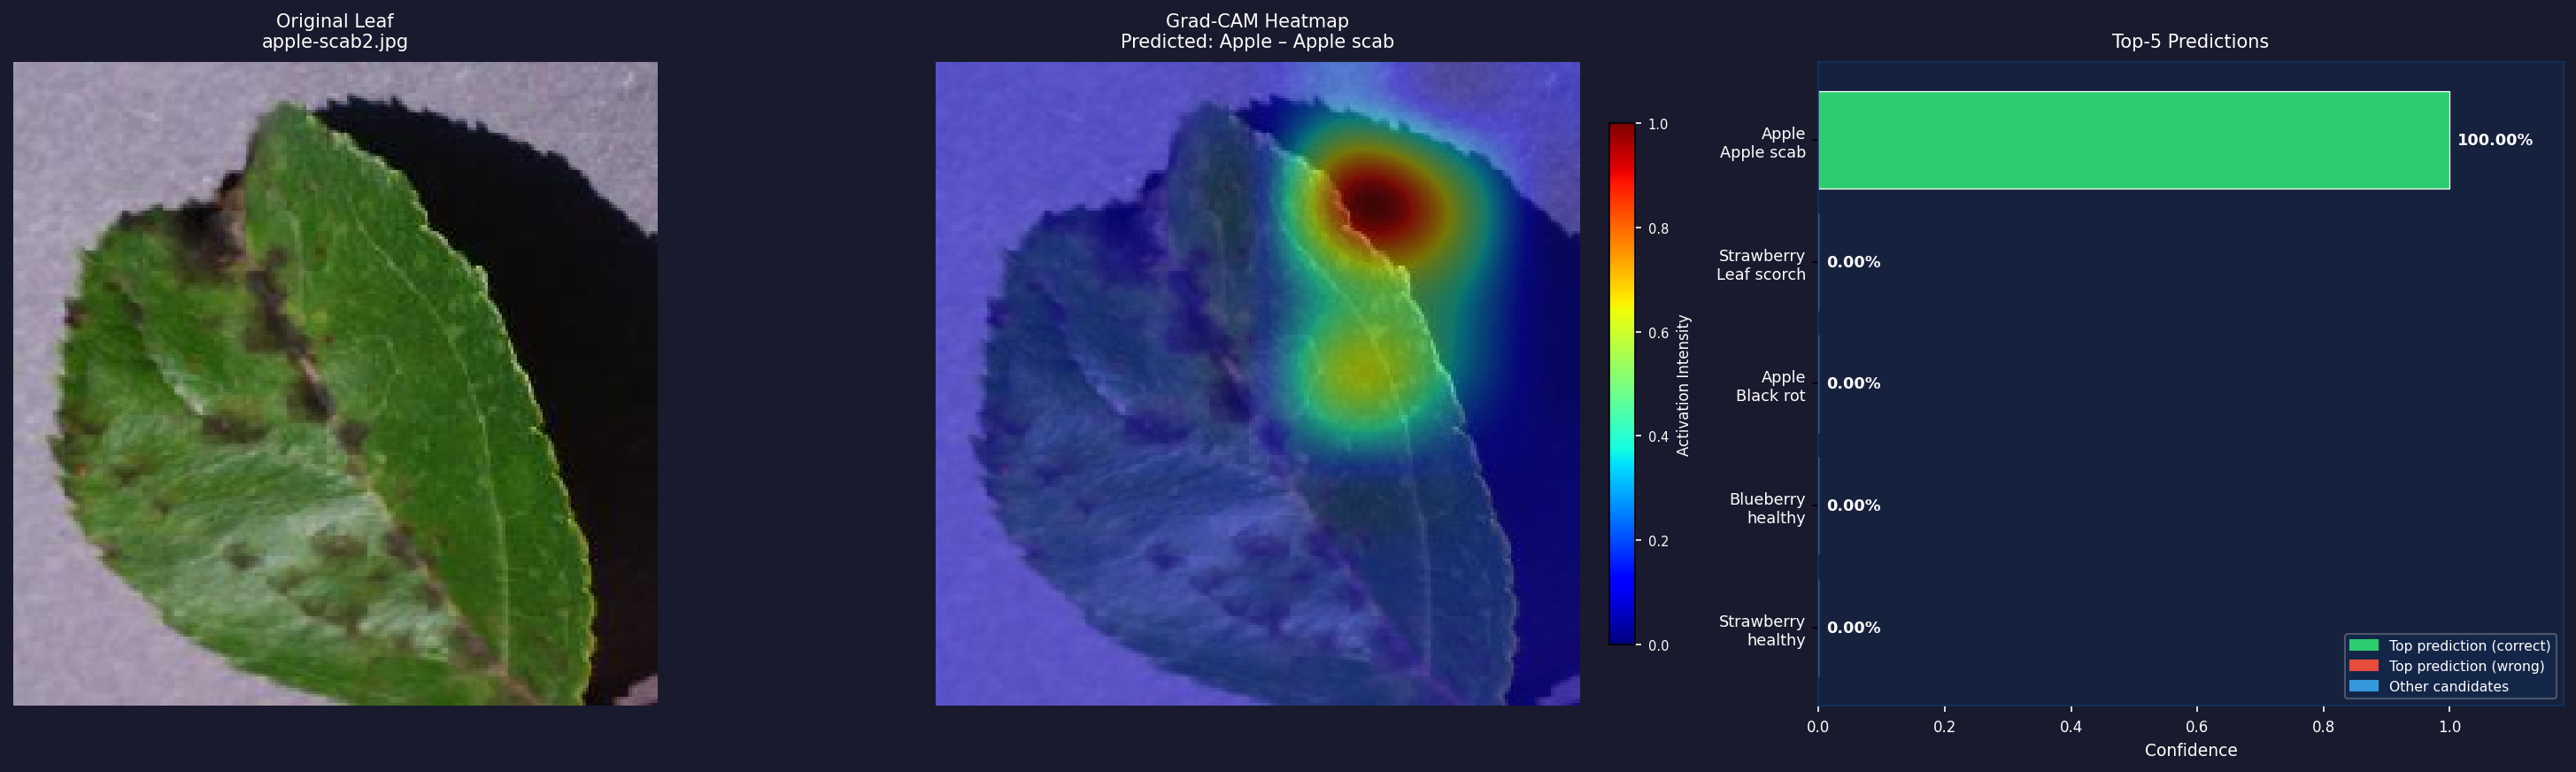

   → Apple___Apple_scab  (100.00%)

📊 Summary:


,Image,Prediction,Confidence
0,apple-scab2.jpg,Apple___Apple_scab,100.00%


In [ ]:
# ── Cell 5: Upload Your Leaf Images & Run Inference ───────────────────────────
#
# You can upload multiple images at once (jpg / jpeg / png).
# Set  TRUE_LABELS  to a dict mapping filename → class name if you want
# the bar chart to colour-code correct vs wrong predictions.
# Leave it as {}  if you only have raw images without ground truth.

TRUE_LABELS = {}   # e.g. {'leaf1.jpg': 'Tomato___Early_blight', ...}

print('Upload one or more leaf images (JPG / PNG):')
uploaded_imgs = files.upload()

OUTPUT_DIR = 'inference_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []

for fname, _ in uploaded_imgs.items():
    print(f'\nProcessing: {fname}')

    try:
        img_arr, img_tensor = preprocess_image(fname)
        heatmap, pred_idx, confidence, all_preds = get_gradcam_heatmap(img_tensor, model)
        true_label = TRUE_LABELS.get(fname, None)

        save_path = os.path.join(OUTPUT_DIR, f'result_{os.path.splitext(fname)[0]}.png')

        make_research_plate(
            img_arr      = img_arr,
            heatmap      = heatmap,
            all_preds    = all_preds,
            pred_idx     = pred_idx,
            true_label   = true_label,
            img_filename = fname,
            save_path    = save_path,
            top_n        = TOP_N
        )

        # Show inline
        display(IPImage(save_path))

        pred_name = CLASS_NAMES[pred_idx]
        results.append({'Image': fname, 'Prediction': pred_name, 'Confidence': f'{confidence:.2%}'})
        print(f'   → {pred_name}  ({confidence:.2%})')

    except Exception as e:
        print(f'   ⚠️  Error on {fname}: {e}')

# Summary table
print('\n📊 Summary:')
display(pd.DataFrame(results))

📂 Upload one or more leaf images (JPG / PNG):


Saving potato-late-blight2.jpg to potato-late-blight2.jpg

🔍 Processing: potato-late-blight2.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


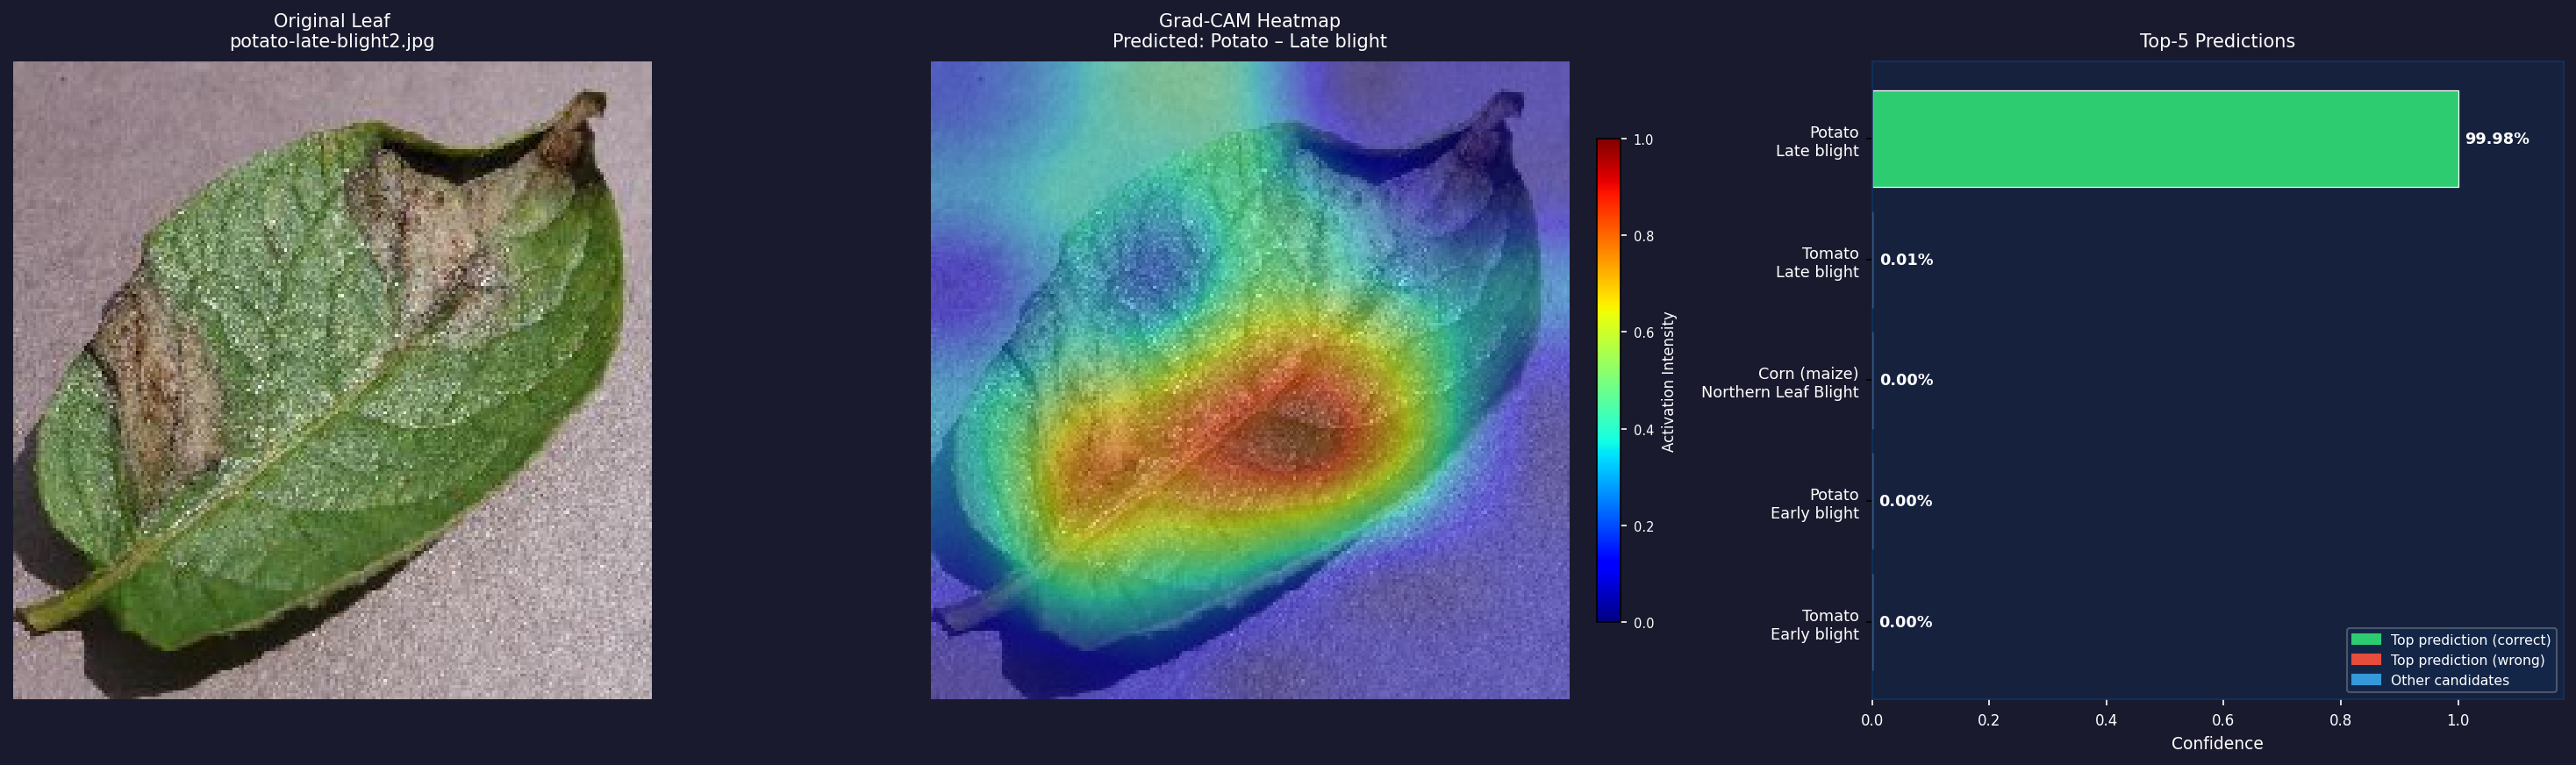

   → Potato___Late_blight  (99.98%)

📊 Summary:


,Image,Prediction,Confidence
0,potato-late-blight2.jpg,Potato___Late_blight,99.98%


In [ ]:
# ── Cell 5: Upload Your Leaf Images & Run Inference ───────────────────────────
#
# You can upload multiple images at once (jpg / jpeg / png).
# Set  TRUE_LABELS  to a dict mapping filename → class name if you want
# the bar chart to colour-code correct vs wrong predictions.
# Leave it as {}  if you only have raw images without ground truth.

TRUE_LABELS = {}   # e.g. {'leaf1.jpg': 'Tomato___Early_blight', ...}

print('📂 Upload one or more leaf images (JPG / PNG):')
uploaded_imgs = files.upload()

OUTPUT_DIR = 'inference_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []

for fname, _ in uploaded_imgs.items():
    print(f'\n🔍 Processing: {fname}')

    try:
        img_arr, img_tensor = preprocess_image(fname)
        heatmap, pred_idx, confidence, all_preds = get_gradcam_heatmap(img_tensor, model)
        true_label = TRUE_LABELS.get(fname, None)

        save_path = os.path.join(OUTPUT_DIR, f'result_{os.path.splitext(fname)[0]}.png')

        make_research_plate(
            img_arr      = img_arr,
            heatmap      = heatmap,
            all_preds    = all_preds,
            pred_idx     = pred_idx,
            true_label   = true_label,
            img_filename = fname,
            save_path    = save_path,
            top_n        = TOP_N
        )

        # Show inline
        display(IPImage(save_path))

        pred_name = CLASS_NAMES[pred_idx]
        results.append({'Image': fname, 'Prediction': pred_name, 'Confidence': f'{confidence:.2%}'})
        print(f'   → {pred_name}  ({confidence:.2%})')

    except Exception as e:
        print(f'   ⚠️  Error on {fname}: {e}')

# Summary table
print('\n📊 Summary:')
display(pd.DataFrame(results))

In [ ]:
# ── Cell 6: Download All Results as ZIP ──────────────────────────────────────
zip_name = 'plant_disease_inference_results.zip'

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for f in os.listdir(OUTPUT_DIR):
        zipf.write(os.path.join(OUTPUT_DIR, f), arcname=f)

print(f'✅ Packaged {len(os.listdir(OUTPUT_DIR))} result(s) → {zip_name}')
files.download(zip_name)

In [ ]:
# ── Cell 7 (OPTIONAL): Run on a whole folder you already have in Colab ────────
# Uncomment and set FOLDER_PATH to the directory containing your leaf images.

# FOLDER_PATH = '/content/my_leaf_images'   # ← change this
# EXTENSIONS  = ('.jpg', '.jpeg', '.png')
#
# image_paths = [os.path.join(FOLDER_PATH, f)
#                for f in sorted(os.listdir(FOLDER_PATH))
#                if f.lower().endswith(EXTENSIONS)]
#
# print(f'Found {len(image_paths)} images in {FOLDER_PATH}')
#
# for img_path in image_paths:
#     fname    = os.path.basename(img_path)
#     img_arr, img_tensor = preprocess_image(img_path)
#     heatmap, pred_idx, confidence, all_preds = get_gradcam_heatmap(img_tensor, model)
#
#     save_path = os.path.join(OUTPUT_DIR, f'result_{os.path.splitext(fname)[0]}.png')
#     make_research_plate(img_arr, heatmap, all_preds, pred_idx,
#                         img_filename=fname, save_path=save_path, top_n=TOP_N)
#     display(IPImage(save_path))
#     print(f'{fname}  →  {CLASS_NAMES[pred_idx]}  ({confidence:.2%})')